In [ ]:
import pandas as pd

# Check files (IMPORTANT)
import os
print(os.listdir())

['.config', 'employee_productivity_dataset.csv', 'sample_data']


In [ ]:
df = pd.read_csv("/content/employee_productivity_dataset.csv")
print(df.head())

  Employee_ID         Name Department   Age  Gender Work_Mode   Join_Date  \
0        E001  Amit Sharma         IT  25.0    Male    Remote  15-01-2021   
1        E002   Riya Patel         HR  30.0  Female    Hybrid  15-02-2020   
2        E003  John Mathew    Finance   NaN    Male    Onsite  10-03-2022   
3        E004  Sneha Joshi         IT  28.0  Female    Remote  22-04-2021   
4        E005  Arjun Verma  Marketing  35.0    Male    Hybrid  18-05-2020   

   Hours_Worked_Per_Week  Projects_Completed  Performance_Score   Salary  \
0                   40.0                   5                4.5  50000.0   
1                   38.0                   4                4.0  45000.0   
2                   45.0                   6                NaN  60000.0   
3                    NaN                   5                4.2  52000.0   
4                   50.0                   7                4.8      NaN   

    Location  
0       Pune  
1     Mumbai  
2  Bangalore  
3      Delhi  
4    

###Q1. Handle Missing Values (Basic Cleaning)

Fill missing values using:

Age → Median
Salary → Mean
Hours_Worked_Per_Week → Median
Performance_Score → Mean
Display the dataset after handling missing values.
###Detailed Explanation

Missing values are common in real-world datasets and can negatively impact machine learning models. Therefore, they must be handled properly.

Different techniques are used based on data type:

Median is used for Age and Hours_Worked_Per_Week because it is not affected by outliers and gives a better central value.
Mean is used for Salary and Performance_Score because it provides an average representation of the data.

Handling missing values improves data quality, consistency, and reliability.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/employee_productivity_dataset.csv")

# Step 1: Check missing values BEFORE
print("Missing values before:")
print(df.isnull().sum())

# Step 2: Fill missing values (as per question)
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Salary'] = df['Salary'].fillna(df['Salary'].mean())
df['Hours_Worked_Per_Week'] = df['Hours_Worked_Per_Week'].fillna(df['Hours_Worked_Per_Week'].median())
df['Performance_Score'] = df['Performance_Score'].fillna(df['Performance_Score'].mean())

# Step 3: Check missing values AFTER
print("\nMissing values after:")
print(df.isnull().sum())

# Step 4: Display dataset
print("\nUpdated Dataset:")
print(df.head())

Missing values before:
Employee_ID               0
Name                      0
Department                0
Age                      25
Gender                    0
Work_Mode                 0
Join_Date                 0
Hours_Worked_Per_Week    50
Projects_Completed        0
Performance_Score        50
Salary                   25
Location                  0
dtype: int64

Missing values after:
Employee_ID              0
Name                     0
Department               0
Age                      0
Gender                   0
Work_Mode                0
Join_Date                0
Hours_Worked_Per_Week    0
Projects_Completed       0
Performance_Score        0
Salary                   0
Location                 0
dtype: int64

Updated Dataset:
  Employee_ID         Name Department   Age  Gender Work_Mode   Join_Date  \
0        E001  Amit Sharma         IT  25.0    Male    Remote  15-01-2021   
1        E002   Riya Patel         HR  30.0  Female    Hybrid  15-02-2020   
2        E003  John

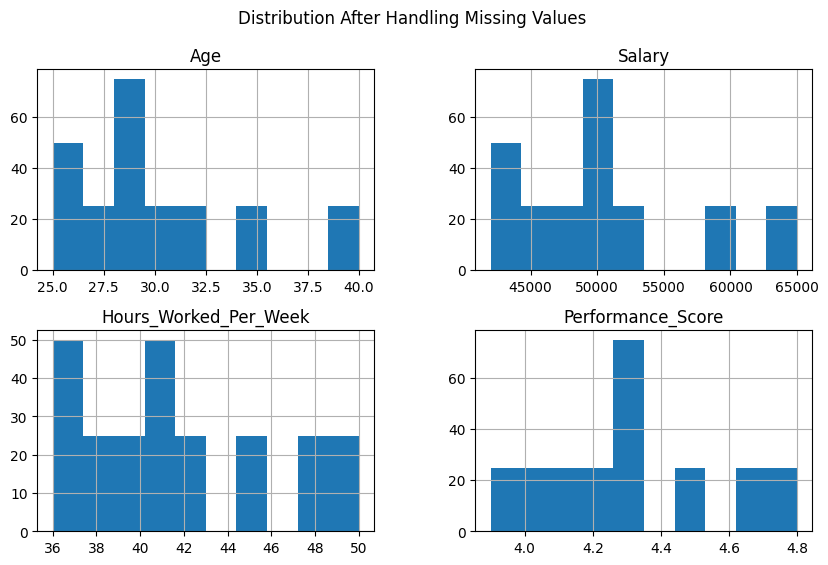

In [ ]:
import matplotlib.pyplot as plt

df[['Age','Salary','Hours_Worked_Per_Week','Performance_Score']].hist(figsize=(10,6))
plt.suptitle("Distribution After Handling Missing Values")
plt.show()

###Output Explanation
Missing values before cleaning are displayed
Missing values are replaced using median and mean
After handling, missing values become zero
Updated dataset is displayed
###Conclusion

“Missing values were successfully handled using median and mean methods. This improved the completeness and quality of the dataset, making it suitable for further analysis.”


###Q2. Label Encoding


Apply Label Encoding on:

Gender
Department
Display the updated dataset.
###Detailed Explanation

Label Encoding is a technique used to convert categorical data into numerical form. Machine learning models cannot understand text values such as “Male”, “Female”, or department names, so these values must be converted into numbers.

In Label Encoding, each unique category is assigned a numerical value. For example:

Male → 0
Female → 1

Similarly, each department is also assigned a unique number. This method is simple and useful when categorical data has no meaningful order.

Label Encoding helps in:

Converting text data into numeric form
Making data suitable for machine learning
Reducing complexity

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Create encoder
le = LabelEncoder()

# Before encoding (important)
print("Before Encoding:")
print(df[['Gender','Department']].head())

# Apply Label Encoding
df['Gender'] = le.fit_transform(df['Gender'])
df['Department'] = le.fit_transform(df['Department'])

# After encoding
print("\nAfter Encoding:")
print(df[['Gender','Department']].head())

Before Encoding:
   Gender Department
0    Male         IT
1  Female         HR
2    Male    Finance
3  Female         IT
4    Male  Marketing

After Encoding:
   Gender  Department
0       1           2
1       0           1
2       1           0
3       0           2
4       1           3


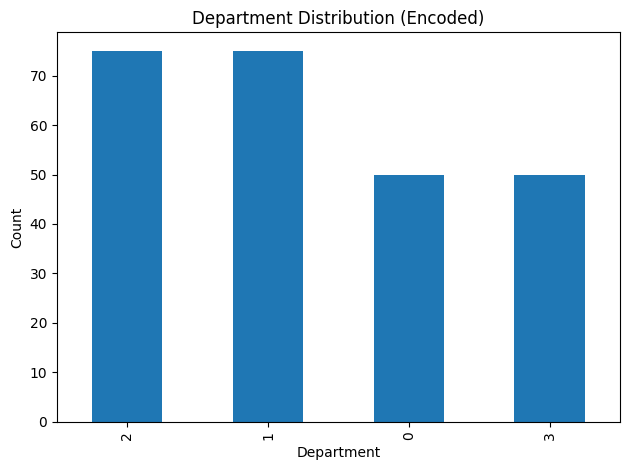

In [ ]:
df['Department'].value_counts().plot(kind='bar')
plt.title("Department Distribution (Encoded)")
plt.xlabel("Department")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

###Output Explanation
Gender and Department columns are converted into numerical values
Each category is assigned a unique number
The dataset is now suitable for machine learning
###Conclusion
 “Label Encoding was successfully applied to Gender and Department. Categorical values were converted into numerical form, making the dataset suitable for machine learning algorithms.”

###Q3. One-Hot Encoding


Apply One-Hot Encoding on:

Work_Mode
Location

Display the dataset and check how many new columns are created.

###Detailed Explanation
One-Hot Encoding is used to convert categorical variables into multiple binary (0/1) columns.
Each category is converted into a separate column, where:

1 → category present
0 → category absent

This helps machine learning models understand categorical data without introducing bias.

In [ ]:
# Apply One-Hot Encoding
df = pd.get_dummies(df, columns=['Work_Mode','Location'])

# Display dataset
print("Updated Dataset:")
print(df.head())

# Check number of columns
print("\nTotal Columns after Encoding:", df.shape[1])

Updated Dataset:
  Employee_ID         Name  Department   Age  Gender   Join_Date  \
0        E001  Amit Sharma           2  25.0       1  15-01-2021   
1        E002   Riya Patel           1  30.0       0  15-02-2020   
2        E003  John Mathew           0  29.0       1  10-03-2022   
3        E004  Sneha Joshi           2  28.0       0  22-04-2021   
4        E005  Arjun Verma           3  35.0       1  18-05-2020   

   Hours_Worked_Per_Week  Projects_Completed  Performance_Score        Salary  \
0                   40.0                   5             4.5000  50000.000000   
1                   38.0                   4             4.0000  45000.000000   
2                   45.0                   6             4.3125  60000.000000   
3                   41.0                   5             4.2000  52000.000000   
4                   50.0                   7             4.8000  50666.666667   

   Work_Mode_Hybrid  Work_Mode_Onsite  Work_Mode_Remote  Location_Bangalore  \
0       

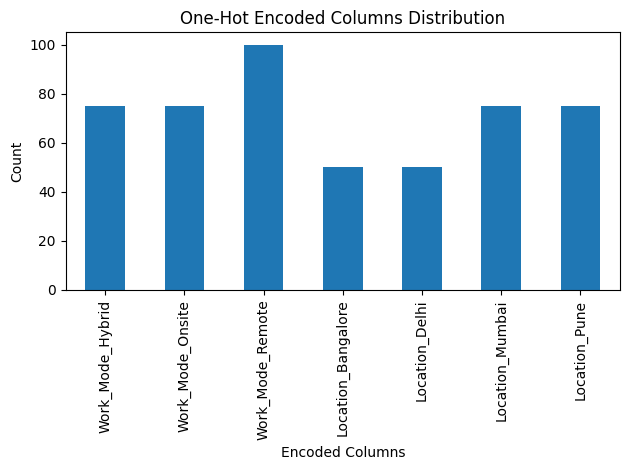

In [ ]:
import matplotlib.pyplot as plt

# Select only encoded columns
encoded_cols = [col for col in df.columns if 'Work_Mode' in col or 'Location' in col]

# Sum of each encoded column
df[encoded_cols].sum().plot(kind='bar')

plt.title("One-Hot Encoded Columns Distribution")
plt.xlabel("Encoded Columns")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

###Output Explanation
One-Hot Encoding creates new columns for each category
Each column contains binary values (0 or 1)
The number of columns increases after encoding
The graph shows the distribution of each encoded category
###Conclusion

“One-Hot Encoding was successfully applied on Work_Mode and Location. New binary columns were created, increasing the total number of columns. This makes categorical data suitable for machine learning models.”

###Q4. Normalization (Min-Max Scaling)


Normalize the following columns:

Salary
Hours_Worked_Per_Week
Use MinMaxScaler and display results.
###Detailed Explanation

Normalization is a technique used to scale data into a fixed range, usually between 0 and 1.

Formula used:

𝑋
𝑠
𝑐
𝑎
𝑙
𝑒
𝑑
=
𝑋
−
𝑋
𝑚
𝑖
𝑛
𝑋
𝑚
𝑎
𝑥
−
𝑋
𝑚
𝑖
𝑛
X
scaled
	​

=
X
max
	​

−X
min
	​

X−X
min
	​

	​


It is useful because:

Removes scale differences between features
Improves model performance
Helps in distance-based algorithms

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Apply normalization
df[['Salary','Hours_Worked_Per_Week']] = scaler.fit_transform(
    df[['Salary','Hours_Worked_Per_Week']]
)

# Display results
print("Normalized Values:")
print(df[['Salary','Hours_Worked_Per_Week']].head())

Normalized Values:
     Salary  Hours_Worked_Per_Week
0  0.347826               0.285714
1  0.130435               0.142857
2  0.782609               0.642857
3  0.434783               0.357143
4  0.376812               1.000000


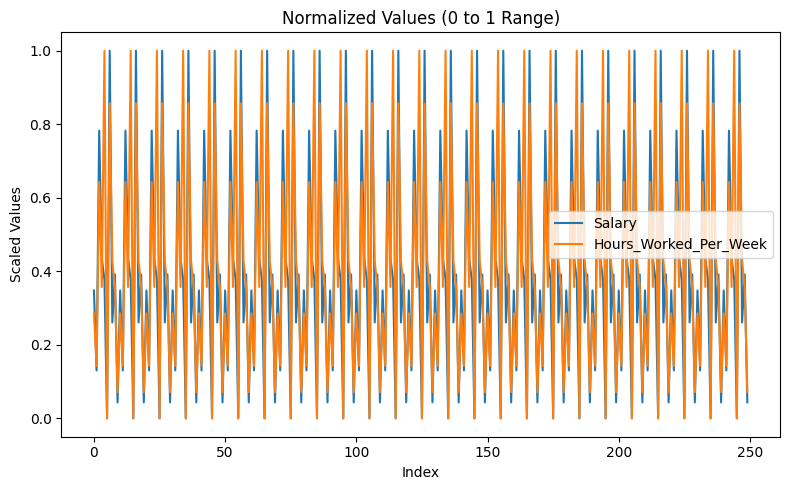

In [ ]:
import matplotlib.pyplot as plt

df[['Salary','Hours_Worked_Per_Week']].plot(kind='line', figsize=(8,5))

plt.title("Normalized Values (0 to 1 Range)")
plt.xlabel("Index")
plt.ylabel("Scaled Values")

plt.tight_layout()
plt.show()

###Output Explanation
Salary and Hours_Worked_Per_Week are scaled between 0 and 1
Minimum value becomes 0 and maximum becomes 1
The dataset is now normalized and ready for further processing
###Conclusion

“Min-Max scaling was applied to Salary and Hours_Worked_Per_Week. The values are now normalized between 0 and 1, improving consistency and model performance.”

###Q5. Standardization (Scaling)


Apply StandardScaler on:

Age
Projects_Completed
Display the transformed values.
###Detailed Explanation

Standardization is a scaling technique that transforms data so that:

Mean = 0
Standard Deviation = 1

Formula:

𝑍
=
𝑋
−
𝜇
𝜎
Z=
σ
X−μ
	​


Where:

𝜇
μ = mean
𝜎
σ = standard deviation

It is useful because:

Centers the data around zero
Removes scale differences
Improves performance of ML algorithms

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Apply standardization
df[['Age','Projects_Completed']] = scaler.fit_transform(
    df[['Age','Projects_Completed']]
)

# Display results
print("Standardized Values:")
print(df[['Age','Projects_Completed']].head())

Standardized Values:
        Age  Projects_Completed
0 -1.172018           -0.211604
1  0.000000           -0.916949
2 -0.234404            0.493742
3 -0.468807           -0.211604
4  1.172018            1.199088


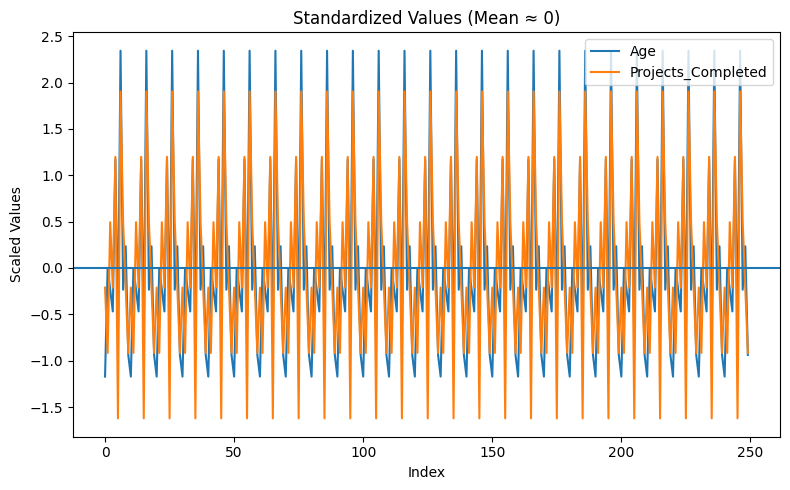

In [ ]:
import matplotlib.pyplot as plt

df[['Age','Projects_Completed']].plot(kind='line', figsize=(8,5))

plt.title("Standardized Values (Mean ≈ 0)")
plt.xlabel("Index")
plt.ylabel("Scaled Values")

plt.axhline(0)  # important line

plt.tight_layout()
plt.show()

###Output Explanation
Age and Projects_Completed are standardized
Values are centered around zero
Both positive and negative values appear
Data is now suitable for machine learning
###Conclusion

“StandardScaler was applied to Age and Projects_Completed. The data is now centered around zero with unit variance, improving consistency and model performance.”

###Q6. Compare Scaling Methods


Apply both:

MinMaxScaler
StandardScaler

On the Salary column.
Show both results side by side.

###Detailed Explanation

Scaling methods are used to transform data into a suitable range for machine learning models. Two commonly used scaling techniques are:

MinMaxScaler:
It scales data between 0 and 1 using the formula:

𝑋
𝑠
𝑐
𝑎
𝑙
𝑒
𝑑
=
𝑋
−
𝑋
𝑚
𝑖
𝑛
𝑋
𝑚
𝑎
𝑥
−
𝑋
𝑚
𝑖
𝑛
X
scaled
	​

=
X
max
	​

−X
min
	​

X−X
min
	​

	​


It preserves the shape of the data but changes the scale.

StandardScaler:
It standardizes data so that the mean becomes 0 and standard deviation becomes 1 using:

𝑍
=
𝑋
−
𝜇
𝜎
Z=
σ
X−μ
	​


Difference:

MinMax → fixed range (0–1)
Standard → centered around 0

This comparison helps in selecting the appropriate scaling method.

In [ ]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

minmax = MinMaxScaler()
standard = StandardScaler()

# Apply both scalers on Salary
df['Salary_MinMax'] = minmax.fit_transform(df[['Salary']])
df['Salary_Standard'] = standard.fit_transform(df[['Salary']])

# Show side by side
print(df[['Salary','Salary_MinMax','Salary_Standard']].head())

     Salary  Salary_MinMax  Salary_Standard
0  0.347826       0.347826    -9.745089e-02
1  0.130435       0.130435    -8.283326e-01
2  0.782609       0.782609     1.364312e+00
3  0.434783       0.434783     1.949018e-01
4  0.376812       0.376812    -3.732632e-16


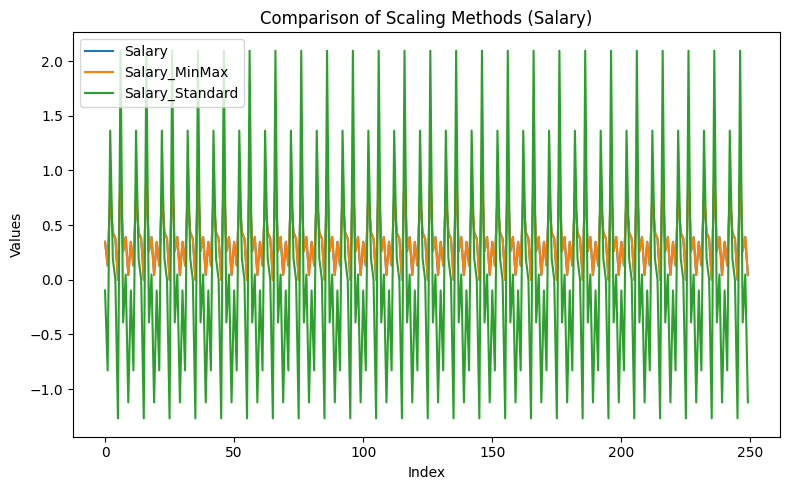

In [ ]:
import matplotlib.pyplot as plt

df[['Salary','Salary_MinMax','Salary_Standard']].plot(figsize=(8,5))

plt.title("Comparison of Scaling Methods (Salary)")
plt.xlabel("Index")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

###Output Explanation
Salary column is transformed using both scaling methods
MinMax values lie between 0 and 1
StandardScaler values are centered around zero
The comparison helps in understanding the difference between scaling techniques
###Conclusion

 “Both MinMaxScaler and StandardScaler were applied to the Salary column. MinMaxScaler scales data between 0 and 1, while StandardScaler centers data around zero. This comparison helps in selecting the appropriate scaling method for machine learning models.”

###Q7. Build Preprocessing Pipeline


Create a pipeline that:

Applies encoding to categorical columns
Applies scaling to numerical columns

Use:

ColumnTransformer
Pipeline
###Detailed Explanation

A preprocessing pipeline is used to automate multiple data transformation steps in a structured manner. Instead of applying encoding and scaling separately, a pipeline combines all steps into one process.

In this question:

Categorical columns are encoded using One-Hot Encoding
Numerical columns are scaled using StandardScaler

We use:

ColumnTransformer → to apply different transformations on different columns
Pipeline → to combine all steps into a single workflow

Benefits:

Reduces manual work
Ensures consistency
Avoids errors
Makes code reusable

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Define columns
num_cols = ['Age','Salary','Hours_Worked_Per_Week','Projects_Completed']
cat_cols = ['Gender','Department','Work_Mode','Location']

# ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

print("Pipeline Created Successfully")

Pipeline Created Successfully


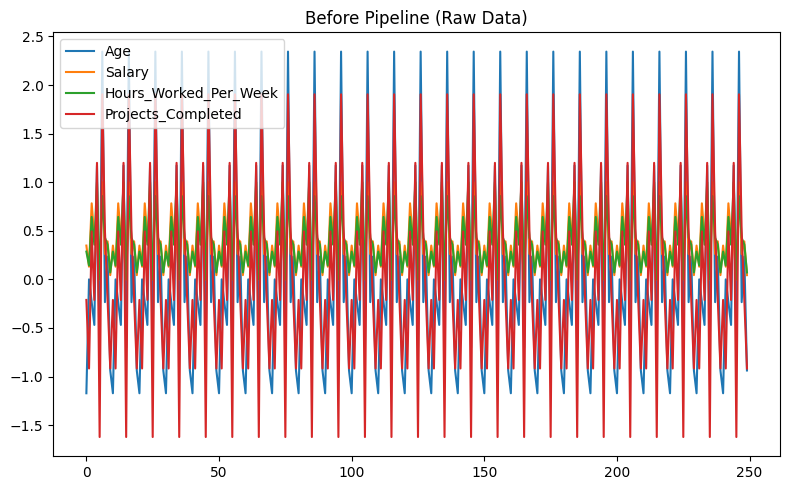

In [ ]:
import matplotlib.pyplot as plt

# Before scaling
df[num_cols].plot(kind='line', figsize=(8,5))
plt.title("Before Pipeline (Raw Data)")
plt.tight_layout()
plt.show()

###Output Explanation
A pipeline is created combining encoding and scaling
ColumnTransformer applies transformations on specific columns
Pipeline ensures all preprocessing steps are executed together
###Conclusion

“A preprocessing pipeline was successfully created using ColumnTransformer and Pipeline. It applies encoding to categorical columns and scaling to numerical columns in a structured and efficient manner.”

###Q8. Apply Pipeline


Apply the pipeline on the dataset.
Display:

Transformed dataset
Shape of final dataset
###Detailed Explanation
After creating the preprocessing pipeline, the next step is to apply it to the dataset. The pipeline automatically performs all transformations such as encoding categorical variables and scaling numerical features.

The output of the pipeline is a transformed dataset in numerical format, which is ready for machine learning models.

 We use:

fit_transform() → to apply all transformations
The output is usually in array format

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# STEP 1: Fresh dataset load (VERY IMPORTANT)
df = pd.read_csv("/content/employee_productivity_dataset.csv")

# STEP 2: Define columns
num_cols = ['Age','Salary','Hours_Worked_Per_Week','Projects_Completed']
cat_cols = ['Gender','Department','Work_Mode','Location']

# STEP 3: Create preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(), cat_cols)
])

# STEP 4: Create pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

# STEP 5: Apply pipeline
transformed_data = pipeline.fit_transform(df)

# STEP 6: Output
print("Transformed Data (First 5 rows):")
print(transformed_data[:5])

print("\nShape of Transformed Data:", transformed_data.shape)

Transformed Data (First 5 rows):
[[-1.14006767 -0.09245003 -0.41039134 -0.21160368  0.          1.
   0.          0.          1.          0.          0.          0.
   1.          0.          0.          0.          1.        ]
 [-0.02478408 -0.78582528 -0.82078268 -0.9169493   1.          0.
   0.          1.          0.          0.          1.          0.
   0.          0.          0.          1.          0.        ]
 [        nan  1.29430046  0.61558701  0.49374193  0.          1.
   1.          0.          0.          0.          0.          1.
   0.          1.          0.          0.          0.        ]
 [-0.47089752  0.18490007         nan -0.21160368  1.          0.
   0.          0.          1.          0.          0.          0.
   1.          0.          1.          0.          0.        ]
 [ 1.09049951         nan  1.64156536  1.19908755  0.          1.
   0.          0.          0.          1.          1.          0.
   0.          0.          0.          0.          1.  

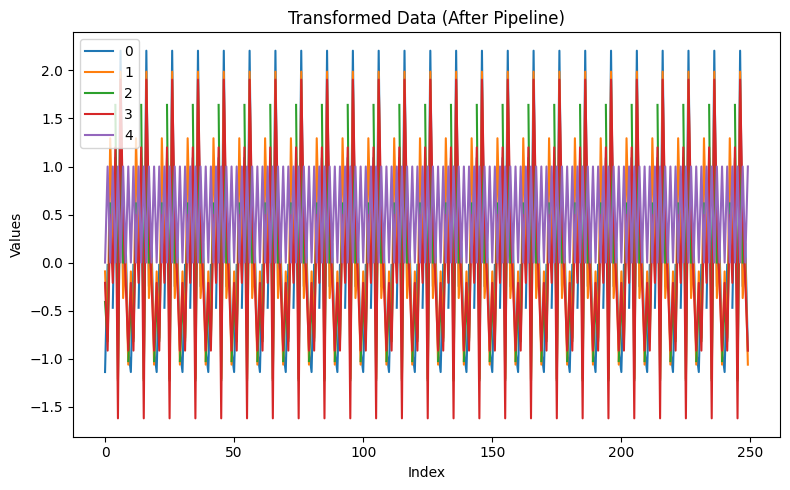

In [ ]:
import matplotlib.pyplot as plt

# Convert to DataFrame for visualization (optional but better)
import pandas as pd
transformed_df = pd.DataFrame(transformed_data)

# Plot first few columns
transformed_df.iloc[:, :5].plot(figsize=(8,5))

plt.title("Transformed Data (After Pipeline)")
plt.xlabel("Index")
plt.ylabel("Values")

plt.tight_layout()
plt.show()

###Output Explanation
Pipeline is successfully applied on the dataset
Data is transformed into numerical format
Categorical variables are encoded and numerical features are scaled
The shape of the dataset changes due to encoding
###Conclusion
“The preprocessing pipeline was successfully applied to the dataset. The transformed data is now in numerical format and ready for machine learning models.”

###Q9. Why is Feature Scaling Important?


Explain why feature scaling is important in machine learning.

###Detailed Explanation

Feature scaling is an important step in data preprocessing where numerical features are transformed to a similar scale. In real-world datasets, different features may have different ranges. For example, salary can be in thousands while age is in tens.

If data is not scaled, machine learning algorithms may give more importance to features with larger values, which leads to biased results.

Feature scaling is important for the following reasons:

Removes scale differences:
It brings all features to the same range, ensuring fair comparison.
Improves model performance:
Algorithms like KNN, SVM, and Logistic Regression perform better when data is scaled.
Faster convergence:
Gradient-based algorithms (like linear regression) converge faster when features are scaled.
Prevents dominance of large values:
Features with large values do not overpower smaller ones.
Better distance calculation:
Distance-based models rely on proper scaling for accurate results.
###Conclusion

 Feature scaling ensures that all features contribute equally to the model. It improves accuracy, efficiency, and overall performance of machine learning algorithms.

###Q10. Why Convert Categorical Data into Numerical Form?


Explain why categorical data must be converted into numerical form in machine learning.

###Detailed Explanation

Categorical data refers to variables that contain labels or text values such as Gender, Department, or Location. Machine learning algorithms cannot directly understand or process these text values because they perform mathematical calculations.

Therefore, categorical data must be converted into numerical form before applying machine learning models.

This conversion is important for the following reasons:

Algorithms require numerical input:
Most machine learning models work on mathematical operations and cannot interpret text data.
Enables computations:
Numerical values allow algorithms to perform calculations such as distance, gradients, and optimization.
Improves model performance:
Proper encoding helps models learn patterns more effectively.
Avoids errors:
Without conversion, models will throw errors or fail to run.
Makes data suitable for analysis:
Encoded data can be easily used for visualization and statistical analysis.

Common techniques used for conversion include:

Label Encoding
One-Hot Encoding
###Conclusion

 Converting categorical data into numerical form is essential for machine learning, as it allows algorithms to process and analyze data effectively, leading to accurate predictions.

Data transformation techniques such as encoding, normalization, and scaling were successfully applied. These steps improved data consistency and prepared the dataset for machine learning models.